## Building probabaility rank a matrix and seeing how it does with ARI
##### With this trial we aim to gather ground-truth blobs from the sklearn datasets, then we will add random gaussian noise to each of these points to simulate our observed blobs, using these observed blobs we will run a Monte Carlo simulation to then compare it to our ground-truth blobs using ARI 

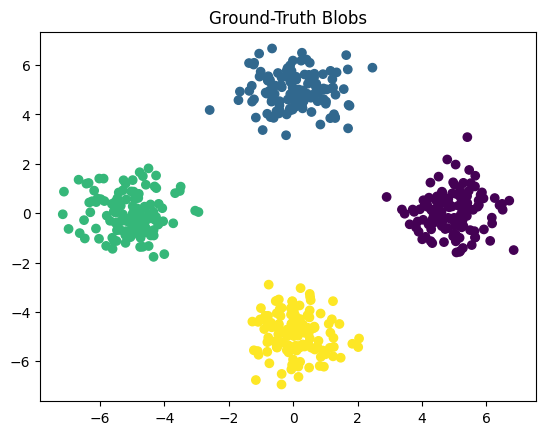

In [2]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, true_labels = make_blobs(
    n_samples = 500,
    centers = [(5, 0), (0, 5), (-5, 0), (0, -5)],
    cluster_std = 0.8,
    random_state = 42
)

plt.scatter(X[:,0], X[:,1], c=true_labels, cmap='viridis')
plt.title("Ground-Truth Blobs")
plt.show ()

### Now we simulate a noise model 
##### We do this by adding random gaussian noise to each point of X simulating our observed X, which is what we will use for our Monte Carlo simulation

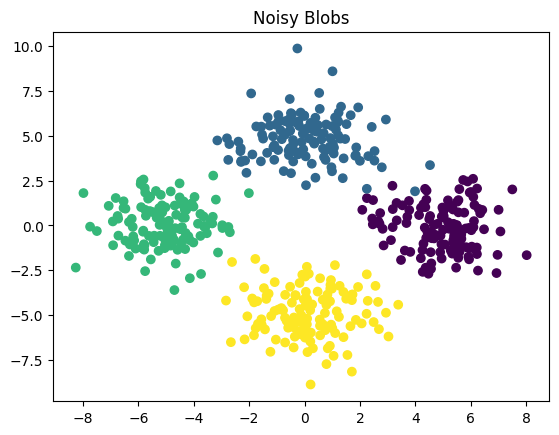

In [3]:
import numpy as np

std = 1.0
X_obs = X + np.random.normal(scale=std, size=X.shape)

plt.scatter(X_obs[:,0], X_obs[:,1], c=true_labels, cmap="viridis")
plt.title("Noisy Blobs")
plt.show()

### With this noise model we can run a Monte Carlo simulation to build our probability rank matrix

In [ ]:
n, _ = X.shape # we have _ because we only care about our noisy datapoints
sims = 500 # number of monte carlo sims
k = 5 # k-nearest neighbours

matrix = np.zeros((n, n), dtype=int)

for t in range(sims):

    X_obs = X + np.random.normal(scale=std, size=X.shape) # making the noisy points every time the sim is ran

    x = np.linalg.norm(X_obs[:,None,:] - X_obs[None,:,:], axis=2) # euclidian norm of the distance between i and j

    for i in range(n):
        sorted_idx = np.argsort(x[i])   # indices of neighbors by distance
        j = sorted_idx[1:k+1]         # skip the first (itself), take next k
        matrix[i, j] += 1             # += 1 every time the point j is in the nearest neighbours of i 

M = matrix/sims # normalize matrix to get the average of every M[i, j] (which is th eproabability of at least k neighbours being closer to i than j is)
print(M)

[[4.   0.   0.01 ... 0.35 0.   0.09]
 [0.   4.   0.   ... 0.   0.07 0.  ]
 [0.01 0.   4.   ... 0.   0.   0.  ]
 ...
 [0.38 0.   0.   ... 4.   0.   0.03]
 [0.   0.09 0.   ... 0.   4.   0.  ]
 [0.08 0.   0.   ... 0.03 0.   4.  ]]


### Running HDBSCAN with our probability rank matrix, and evaluating perfromance with ARI (Adjusted Rand Index)